In [1]:
!ls /kaggle/input/datasets/emmarex/plantdisease/PlantVillage

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [2]:
DATASET_ROOT = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
print("Dataset setup complete.")

Dataset setup complete.


In [3]:

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import timm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:


PEPPER_BACTERIAL = 'Pepper__bell___Bacterial_spot'
PEPPER_HEALTHY   = 'Pepper__bell___healthy'

CLASS_NAMES = ['Bacterial Spot', 'Healthy']  # Human-readable labels
FOLDER_TO_IDX = {
    PEPPER_BACTERIAL: 0,
    PEPPER_HEALTHY:   1
}


In [5]:

class PepperLeafDataset(Dataset):
    def __init__(self, root_dir, class_folders, transform=None):
        self.transform = transform
        self.samples = []  
        self.labels  = []

        for folder_name in class_folders:
            folder_path = os.path.join(root_dir, folder_name)
            label = FOLDER_TO_IDX[folder_name]   # 0 or 1

            if not os.path.isdir(folder_path):
                print(f"WARNING: folder not found: {folder_path}")
                continue

            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(folder_path, fname), label))
                    self.labels.append(label)

        print(f"Total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)   # Apply augmentation / normalization

        return image, label


In [6]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms include data augmentation to improve generalization
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),              # Upscale/downscale to 256×256
    transforms.RandomCrop(224),                 # Random crop to 224×224 (EfficientNet input)
    transforms.RandomHorizontalFlip(p=0.5),     # Flip left-right randomly
    transforms.RandomVerticalFlip(p=0.3),       # Flip up-down (leaves look similar either way)
    transforms.ColorJitter(                     # Simulate different lighting conditions
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.RandomRotation(degrees=15),      # Slight rotation (leaves can be at any angle)
    transforms.ToTensor(),                      # Convert PIL Image → torch.Tensor [0,1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # Normalize to ImageNet distribution
])

# Validation/Test transforms: only resize + center crop + normalize (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms defined.")


Transforms defined.


In [7]:


CLASS_FOLDERS = [PEPPER_BACTERIAL, PEPPER_HEALTHY]

# Load all images with train_transform first (we'll reassign transforms after splitting)
full_dataset = PepperLeafDataset(
    root_dir=DATASET_ROOT,
    class_folders=CLASS_FOLDERS,
    transform=train_transform
)

# Split sizes: 70% train, 15% val, 15% test
total = len(full_dataset)
print(total)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

print(f"Total: {total} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

# random_split gives Subset objects; we fix the seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

class TransformSubset(Dataset):
    """Wraps a Subset and applies a custom transform, overriding the parent dataset's."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = TransformSubset(train_subset, train_transform)
val_ds   = TransformSubset(val_subset,   val_transform)
test_ds  = TransformSubset(test_subset,  val_transform)

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Total samples loaded: 2475
2475
Total: 2475 | Train: 1732 | Val: 371 | Test: 372
Batches — Train: 55 | Val: 12 | Test: 12


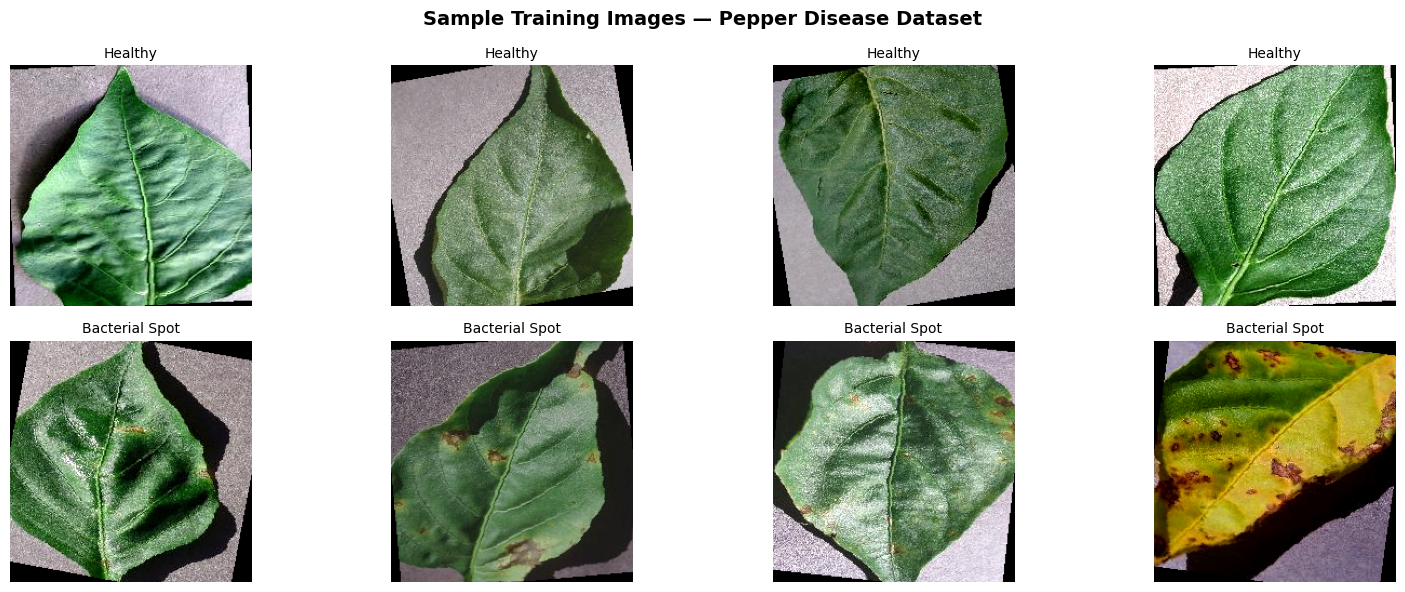

Saved: sample_images.png


In [8]:


def imshow_grid(dataset, n=8, title="Sample Images"):
    """Display a grid of images from a dataset."""
    fig, axes = plt.subplots(2, n//2, figsize=(16, 6))
    axes = axes.flatten()

    # Pick random indices
    indices = random.sample(range(len(dataset)), n)

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]

        # Unnormalize: reverse the ImageNet normalization for display
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img  = img_tensor * std + mean   # Inverse normalize
        img  = img.clamp(0, 1)           # Clamp to valid range

        # Convert from (C, H, W) to (H, W, C) for matplotlib
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title(CLASS_NAMES[label], fontsize=10)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: sample_images.png")

imshow_grid(train_ds, n=8, title="Sample Training Images — Pepper Disease Dataset")


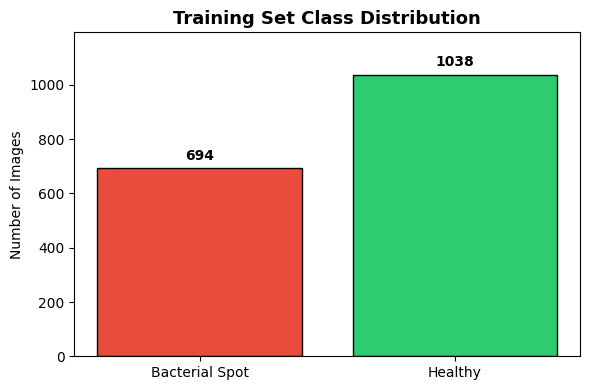

Saved: class_distribution.png


In [9]:

def plot_class_distribution(dataset, title="Class Distribution"):
    """Bar chart showing how many images per class."""
    labels = [dataset[i][1] for i in range(len(dataset))]
    counts = [labels.count(0), labels.count(1)]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(CLASS_NAMES, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')

    # Annotate bars with counts
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                str(count), ha='center', va='bottom', fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(counts) * 1.15)
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: class_distribution.png")

plot_class_distribution(train_ds, "Training Set Class Distribution")


In [10]:


def build_model(num_classes=2, pretrained=True):
    """
    Load EfficientNet-B0 pretrained on ImageNet from timm,
    replace the classifier head for our binary task.
    """
    model = timm.create_model(
        'efficientnet_b0',
        pretrained=pretrained,   # Download ImageNet weights
        num_classes=num_classes  # Replace final FC layer: 1280 → 2
    )
    return model

model = build_model(num_classes=2, pretrained=True)
model = model.to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total parameters:     4,010,110
Trainable parameters: 4,010,110


In [11]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,   # Number of epochs for one cosine cycle
    eta_min=1e-6
)

print("Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)")
print("Scheduler: CosineAnnealingLR (T_max=10, eta_min=1e-6)")


Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
Scheduler: CosineAnnealingLR (T_max=10, eta_min=1e-6)


In [12]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()   # Enable dropout, batch norm in training mode
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images = images.to(device)   # Move batch to GPU
        labels = labels.to(device)

        optimizer.zero_grad()          # Reset accumulated gradients
        outputs = model(images)        # Forward pass → logits shape (B, 2)
        loss = criterion(outputs, labels)  # Compute cross-entropy loss
        loss.backward()                # Backpropagate gradients
        optimizer.step()               # Update weights

        # Accumulate statistics
        total_loss += loss.item() * images.size(0)  # Weighted by batch size
        preds = outputs.argmax(dim=1)               # Predicted class indices
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()   # Disable dropout; use running stats for batch norm
    total_loss, correct, total = 0.0, 0, 0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():   # No gradient computation needed at inference
        for images, labels in tqdm(loader, desc="  Eval ", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)                # Logits: shape (B, 2)
            loss    = criterion(outputs, labels)

            probs  = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
            preds  = probs.argmax(dim=1)            # Predicted class

            total_loss += loss.item() * images.size(0)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1 (Healthy)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)



In [13]:


NUM_EPOCHS   = 10      # Number of training epochs
PATIENCE     = 3       # Early stopping: stop if val loss doesn't improve for 3 epochs
SAVE_PATH    = 'models/pepper_model.pth'

os.makedirs('models', exist_ok=True)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_loss   = float('inf')
patience_counter = 0

print(f"\nTraining EfficientNet-B0 for up to {NUM_EPOCHS} epochs on {DEVICE}...")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (LR: {scheduler.get_last_lr()[0]:.2e})")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc*100:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'val_loss':    val_loss,
            'val_acc':     val_acc,
            'class_names': CLASS_NAMES
        }, SAVE_PATH)
        print(f"  ✓ Saved best model (val_loss improved to {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

print("\n" + "=" * 60)
print("Training complete!")



Training EfficientNet-B0 for up to 10 epochs on cuda...

Epoch 1/10  (LR: 1.00e-04)


  Train Loss: 0.3407 | Train Acc: 91.11%
  Val   Loss: 0.0380  | Val   Acc: 97.30%
  ✓ Saved best model (val_loss improved to 0.0380)

Epoch 2/10  (LR: 9.76e-05)


  Train Loss: 0.0865 | Train Acc: 98.21%
  Val   Loss: 0.0176  | Val   Acc: 98.92%
  ✓ Saved best model (val_loss improved to 0.0176)

Epoch 3/10  (LR: 9.05e-05)


  Train Loss: 0.0813 | Train Acc: 98.38%
  Val   Loss: 0.0260  | Val   Acc: 99.19%
  No improvement (1/3)

Epoch 4/10  (LR: 7.96e-05)


  Train Loss: 0.0601 | Train Acc: 98.73%
  Val   Loss: 0.0050  | Val   Acc: 99.73%
  ✓ Saved best model (val_loss improved to 0.0050)

Epoch 5/10  (LR: 6.58e-05)


...

  Train Loss: 0.0134 | Train Acc: 99.48%
  Val   Loss: 0.0017  | Val   Acc: 100.00%
  ✓ Saved best model (val_loss improved to 0.0017)

Epoch 7/10  (LR: 3.52e-05)


  Train Loss: 0.0173 | Train Acc: 99.31%
  Val   Loss: 0.0053  | Val   Acc: 99.73%
  No improvement (1/3)

Epoch 8/10  (LR: 2.14e-05)


  Train Loss: 0.0189 | Train Acc: 99.36%
  Val   Loss: 0.0007  | Val   Acc: 100.00%
  ✓ Saved best model (val_loss improved to 0.0007)

Epoch 9/10  (LR: 1.05e-05)


  Train Loss: 0.0262 | Train Acc: 99.25%
  Val   Loss: 0.0008  | Val   Acc: 100.00%
  No improvement (1/3)

Epoch 10/10  (LR: 3.42e-06)


  Train Loss: 0.0183 | Train Acc: 99.48%
  Val   Loss: 0.0006  | Val   Acc: 100.00%
  ✓ Saved best model (val_loss improved to 0.0006)

Training complete!


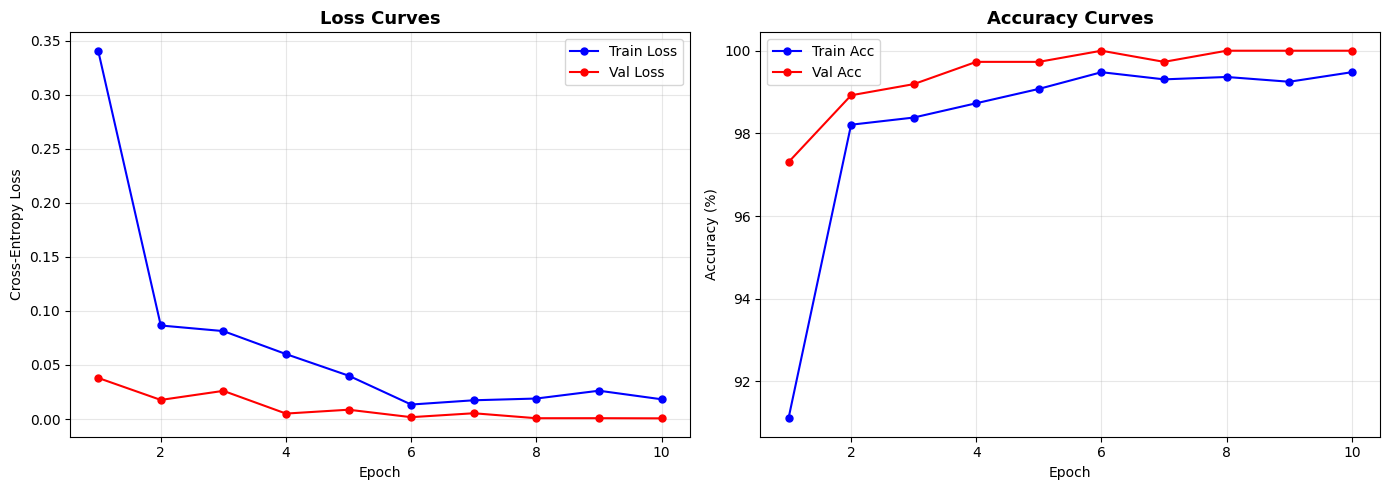

Saved: training_curves.png


In [14]:


def plot_training_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=5)
    ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=5)
    ax1.set_title('Loss Curves', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=5)
    ax2.plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=5)
    ax2.set_title('Accuracy Curves', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")

plot_training_curves(history)


In [15]:

checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f})")

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))


Loaded best model from epoch 10 (val_loss=0.0006)



Test Loss:     0.0120
Test Accuracy: 99.73%

Classification Report:
                precision    recall  f1-score   support

Bacterial Spot     0.9938    1.0000    0.9969       161
       Healthy     1.0000    0.9953    0.9976       211

      accuracy                         0.9973       372
     macro avg     0.9969    0.9976    0.9973       372
  weighted avg     0.9973    0.9973    0.9973       372



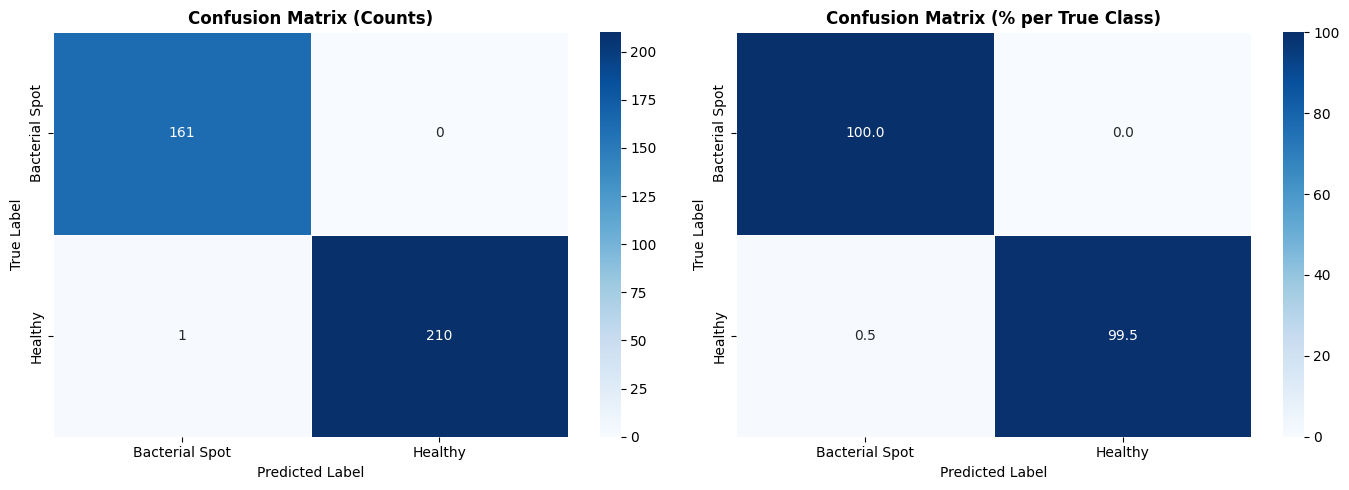

Saved: confusion_matrix.png


In [16]:

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title(f'{title} (Counts)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], linewidths=0.5,
                vmin=0, vmax=100)
    axes[1].set_title(f'{title} (% per True Class)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

plot_confusion_matrix(test_labels, test_preds, CLASS_NAMES)


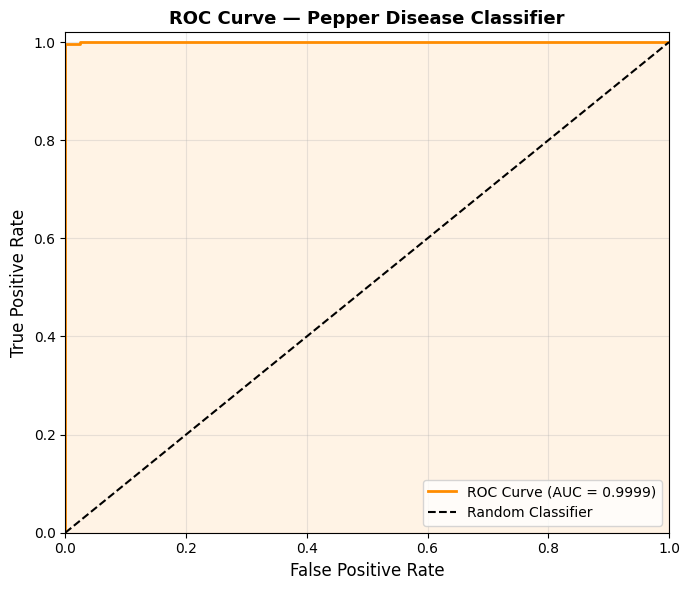

Saved: roc_curve.png  |  AUC = 0.9999


In [17]:

def plot_roc_curve(y_true, y_probs, title="ROC Curve"):
    """Plot Receiver Operating Characteristic curve."""
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: roc_curve.png  |  AUC = {roc_auc:.4f}")
    return roc_auc

roc_auc = plot_roc_curve(test_labels, test_probs, "ROC Curve — Pepper Disease Classifier")


In [18]:

def per_class_accuracy(y_true, y_pred, class_names):
    """Print per-class precision, recall, F1."""
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names)))
    )
    print(f"\n{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 60)
    for i, name in enumerate(class_names):
        print(f"{name:<20} {precision[i]:>10.4f} {recall[i]:>10.4f} "
              f"{f1[i]:>10.4f} {support[i]:>10d}")

per_class_accuracy(test_labels, test_preds, CLASS_NAMES)



Class                 Precision     Recall         F1    Support
------------------------------------------------------------
Bacterial Spot           0.9938     1.0000     0.9969        161
Healthy                  1.0000     0.9953     0.9976        211


In [19]:


print("\n" + "="*60)
print("ABLATION STUDY: Pretrained vs Random Initialization")
print("="*60)

def quick_train_eval(pretrained: bool, epochs: int = 3):
    """Train for a few epochs and return test accuracy."""
    mdl = build_model(num_classes=2, pretrained=pretrained).to(DEVICE)
    opt = optim.AdamW(mdl.parameters(), lr=1e-4, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    for ep in range(epochs):
        mdl.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad()
            loss = crit(mdl(imgs), lbls)
            loss.backward()
            opt.step()

    _, acc, _, _, _ = evaluate(mdl, test_loader, crit, DEVICE)
    return acc

print("Training pretrained model (3 epochs)...")
acc_pretrained = quick_train_eval(pretrained=True,  epochs=3)

print("Training from-scratch model (3 epochs)...")
acc_scratch    = quick_train_eval(pretrained=False, epochs=3)

print(f"\n{'Model':<30} {'Test Accuracy':>15}")
print("-"*45)
print(f"{'EfficientNet-B0 (pretrained)':<30} {acc_pretrained*100:>14.2f}%")
print(f"{'EfficientNet-B0 (from scratch)':<30} {acc_scratch*100:>14.2f}%")
print(f"{'Improvement from pretraining':<30} {(acc_pretrained-acc_scratch)*100:>+14.2f}%")



ABLATION STUDY: Pretrained vs Random Initialization
Training pretrained model (3 epochs)...


Training from-scratch model (3 epochs)...



Model                            Test Accuracy
---------------------------------------------
EfficientNet-B0 (pretrained)            99.19%
EfficientNet-B0 (from scratch)          49.19%
Improvement from pretraining           +50.00%


In [20]:

disease_info = {
    "Bacterial Spot": {
        "description": (
            "Bacterial Spot (Xanthomonas campestris pv. vesicatoria) causes small, "
            "water-soaked spots on pepper leaves that turn brown and necrotic with "
            "yellow halos. Severely infected leaves drop early, reducing photosynthesis "
            "and yield significantly."
        ),
        "symptoms": [
            "Small dark-brown spots (2–10 mm) with yellow halo on leaves",
            "Irregular, greasy-looking lesions on fruit and stems",
            "Premature leaf drop and defoliation",
            "Lesions may merge to form large blighted areas"
        ],
        "cause": "Xanthomonas campestris pv. vesicatoria (bacterial pathogen)",
        "recommended_actions": [
            "Remove and destroy infected plant parts immediately",
            "Apply copper-based bactericide (e.g., Blitox-50 or Kocide)",
            "Avoid overhead irrigation; use drip irrigation",
            "Plant resistant varieties in the next season",
            "Practice crop rotation — avoid planting pepper/tomato in same plot"
        ],
        "severity": "High — can cause 20–30% yield loss if untreated",
        "urgency": "🔴 Act within 24–48 hours"
    },
    "Healthy": {
        "description": (
            "Your pepper plant appears healthy! The leaves show no signs of disease, "
            "with uniform green color, no spots or lesions, and normal shape. "
            "Continue your current care routine to maintain plant health."
        ),
        "symptoms": [
            "Uniform green leaf color",
            "No spots, lesions, or discoloration",
            "Normal leaf shape and texture",
            "Vigorous growth"
        ],
        "cause": "No disease detected",
        "recommended_actions": [
            "Continue regular watering and fertilization schedule",
            "Monitor weekly for early signs of disease",
            "Maintain good air circulation around plants",
            "Apply preventive neem oil spray every 2 weeks",
            "Keep field clean of plant debris"
        ],
        "severity": "None — plant is healthy",
        "urgency": "🟢 No immediate action needed"
    }
}

with open('disease_info.json', 'w') as f:
    json.dump(disease_info, f, indent=2)

print("Saved: disease_info.json")
print(json.dumps(disease_info, indent=2))


Saved: disease_info.json
{
  "Bacterial Spot": {
    "description": "Bacterial Spot (Xanthomonas campestris pv. vesicatoria) causes small, water-soaked spots on pepper leaves that turn brown and necrotic with yellow halos. Severely infected leaves drop early, reducing photosynthesis and yield significantly.",
    "symptoms": [
      "Small dark-brown spots (2\u201310 mm) with yellow halo on leaves",
      "Irregular, greasy-looking lesions on fruit and stems",
      "Premature leaf drop and defoliation",
      "Lesions may merge to form large blighted areas"
    ],
    "cause": "Xanthomonas campestris pv. vesicatoria (bacterial pathogen)",
    "recommended_actions": [
      "Remove and destroy infected plant parts immediately",
      "Apply copper-based bactericide (e.g., Blitox-50 or Kocide)",
      "Avoid overhead irrigation; use drip irrigation",
      "Plant resistant varieties in the next season",
      "Practice crop rotation \u2014 avoid planting pepper/tomato in same plot"
    

In [21]:

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted'
)

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Test Accuracy:        {test_acc*100:.2f}%")
print(f"Weighted Precision:   {precision*100:.2f}%")
print(f"Weighted Recall:      {recall*100:.2f}%")
print(f"Weighted F1-Score:    {f1*100:.2f}%")
print(f"ROC-AUC Score:        {roc_auc:.4f}")
print(f"Best Val Loss:        {best_val_loss:.4f}")
print(f"Model saved to:       {SAVE_PATH}")
print("="*60)

# Copy model to Google Drive for persistence
!cp models/pepper_model.pth '/content/drive/MyDrive/pepper_model.pth'
print("Model copied to Google Drive.")


FINAL RESULTS SUMMARY
Test Accuracy:        99.73%
Weighted Precision:   99.73%
Weighted Recall:      99.73%
Weighted F1-Score:    99.73%
ROC-AUC Score:        0.9999
Best Val Loss:        0.0006
Model saved to:       models/pepper_model.pth
cp: cannot create regular file '/content/drive/MyDrive/pepper_model.pth': No such file or directory
Model copied to Google Drive.


In [22]:
!du -sh /kaggle/working/models/*

16M	/kaggle/working/models/pepper_model.pth
